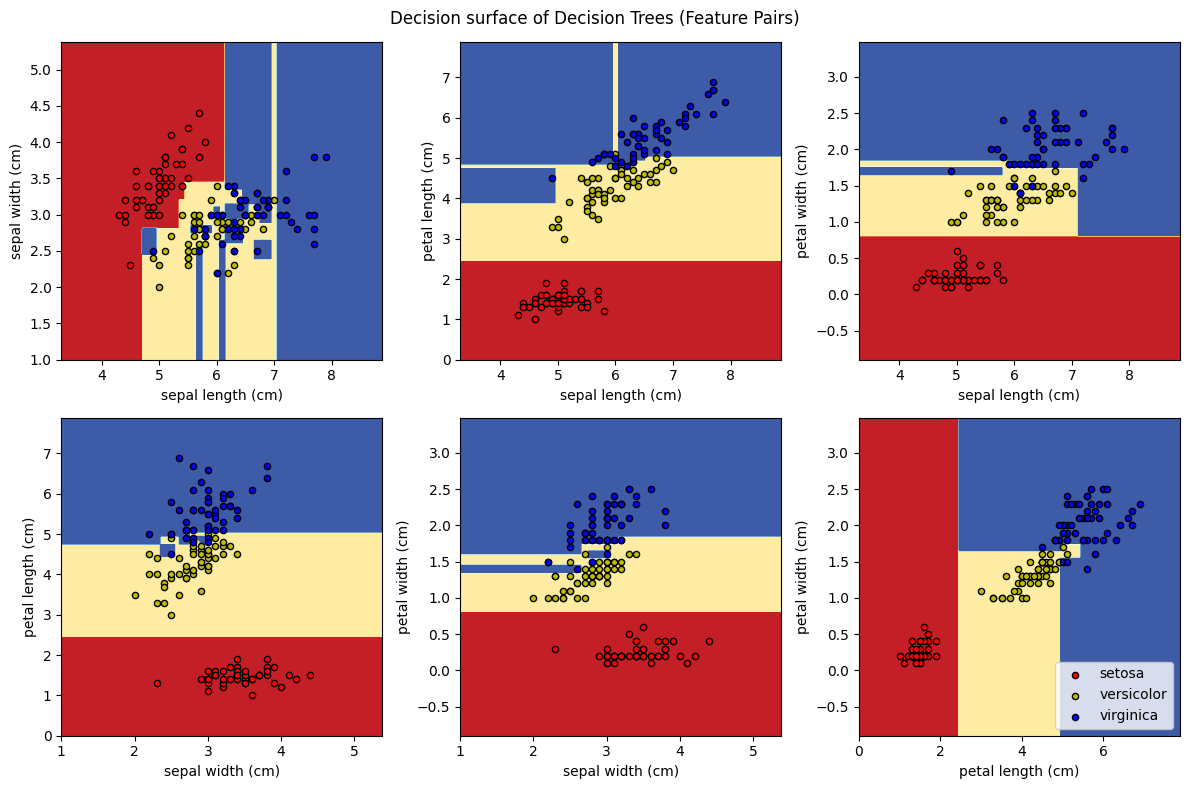

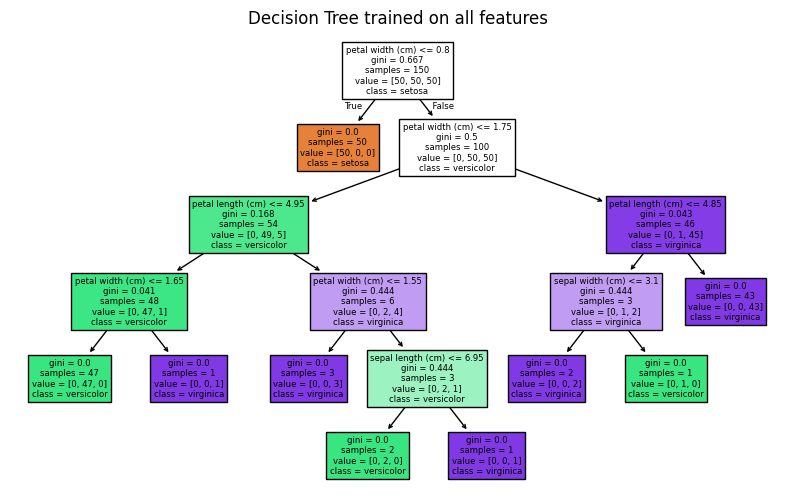

In [1]:
# Import libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier, plot_tree

# Load dataset
iris = load_iris()
X = iris.data
y = iris.target

# Parameters
n_classes = 3
plot_colors = "ryb"
plot_step = 0.02

# Plot decision boundaries for feature pairs
plt.figure(figsize=(12, 8))

for pairidx, pair in enumerate([[0,1], [0,2], [0,3], [1,2], [1,3], [2,3]]):
    X_pair = X[:, pair]

    # Train model
    clf = DecisionTreeClassifier()
    clf.fit(X_pair, y)

    # Plot setup
    plt.subplot(2, 3, pairidx + 1)

    x_min, x_max = X_pair[:, 0].min() - 1, X_pair[:, 0].max() + 1
    y_min, y_max = X_pair[:, 1].min() - 1, X_pair[:, 1].max() + 1

    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, plot_step),
        np.arange(y_min, y_max, plot_step)
    )

    # Predict
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # Plot decision boundary
    plt.contourf(xx, yy, Z, cmap=plt.cm.RdYlBu)

    # Plot training points
    for i, color in zip(range(n_classes), plot_colors):
        idx = np.where(y == i)
        plt.scatter(X_pair[idx, 0], X_pair[idx, 1],
                    c=color, label=iris.target_names[i],
                    edgecolor='black', s=20)

    plt.xlabel(iris.feature_names[pair[0]])
    plt.ylabel(iris.feature_names[pair[1]])
    plt.axis("tight")

plt.suptitle("Decision surface of Decision Trees (Feature Pairs)")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

# Plot final decision tree using all features
clf_full = DecisionTreeClassifier()
clf_full.fit(X, y)

plt.figure(figsize=(10, 6))
plot_tree(clf_full, filled=True,
          feature_names=iris.feature_names,
          class_names=iris.target_names)
plt.title("Decision Tree trained on all features")
plt.show()